In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

In [18]:
df = pd.read_csv('/content/data.csv')
df

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09 00:00:00,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA
4596,2014-07-09 00:00:00,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,2014-07-09 00:00:00,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,2014-07-10 00:00:00,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA


In [19]:
import datetime as dt
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,sqft_basement,yr_built,yr_renovated,street,city,statezip,country,year,month,day
0,2014-05-02,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,...,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA,2014,5,2
1,2014-05-02,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,...,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA,2014,5,2
2,2014-05-02,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,...,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA,2014,5,2
3,2014-05-02,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,...,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA,2014,5,2
4,2014-05-02,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,...,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA,2014,5,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,...,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA,2014,7,9
4596,2014-07-09,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,...,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA,2014,7,9
4597,2014-07-09,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,...,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA,2014,7,9
4598,2014-07-10,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,...,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA,2014,7,10


In [20]:
df = df.drop(['date','street','statezip'],axis=1)
df

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,country,year,month,day
0,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,USA,2014,5,2
1,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle,USA,2014,5,2
2,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,USA,2014,5,2
3,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue,USA,2014,5,2
4,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond,USA,2014,5,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,Seattle,USA,2014,7,9
4596,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,Bellevue,USA,2014,7,9
4597,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,Renton,USA,2014,7,9
4598,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,Seattle,USA,2014,7,10


In [21]:
a = {}
s = 0
for i in df['city']:
  if i not in a:
    a[i] = s
    s = s + 1
  else:
    pass
print(a)

{'Shoreline': 0, 'Seattle': 1, 'Kent': 2, 'Bellevue': 3, 'Redmond': 4, 'Maple Valley': 5, 'North Bend': 6, 'Lake Forest Park': 7, 'Sammamish': 8, 'Auburn': 9, 'Des Moines': 10, 'Bothell': 11, 'Federal Way': 12, 'Kirkland': 13, 'Issaquah': 14, 'Woodinville': 15, 'Normandy Park': 16, 'Fall City': 17, 'Renton': 18, 'Carnation': 19, 'Snoqualmie': 20, 'Duvall': 21, 'Burien': 22, 'Covington': 23, 'Inglewood-Finn Hill': 24, 'Kenmore': 25, 'Newcastle': 26, 'Mercer Island': 27, 'Black Diamond': 28, 'Ravensdale': 29, 'Clyde Hill': 30, 'Algona': 31, 'Skykomish': 32, 'Tukwila': 33, 'Vashon': 34, 'Yarrow Point': 35, 'SeaTac': 36, 'Medina': 37, 'Enumclaw': 38, 'Snoqualmie Pass': 39, 'Pacific': 40, 'Beaux Arts Village': 41, 'Preston': 42, 'Milton': 43}


In [22]:
df['city'] = df['city'].map(a).astype(int)
df['country'] = df['country'].map({'USA':1})
df

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,country,year,month,day
0,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,0,1,2014,5,2
1,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,1,1,2014,5,2
2,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,2,1,2014,5,2
3,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,3,1,2014,5,2
4,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,4,1,2014,5,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,1,1,2014,7,9
4596,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,3,1,2014,7,9
4597,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,18,1,2014,7,9
4598,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,1,1,2014,7,10


In [23]:
x = df.iloc[:,1:]
y = df.iloc[:,0]

In [24]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=1)

In [25]:
len(x_train), len(y_train)

(3680, 3680)

In [26]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(x_train,y_train)

LinearRegression()

In [27]:
#m value
reg.coef_

array([-4.92596215e+04,  5.37341297e+04,  1.61260630e+02, -4.44432226e-01,
        1.30830725e+04,  6.37512516e+05,  3.65344855e+04,  3.77236711e+04,
        1.05925674e+02,  5.53349562e+01, -1.75477619e+03,  7.95985744e+00,
       -4.82942966e+03, -1.01863407e-10,  0.00000000e+00,  1.88337365e+04,
       -5.81491800e+02])

In [28]:
#c value
reg.intercept_

np.float64(3288709.4007666283)

**Manual m and c Value**

In [29]:
#Manual m and c values using matrix multiplication
import numpy as np

# --- Convert pandas to numpy ---
X_np = x_train.values
y_np = y_train.values.reshape(-1, 1)

# --- Compute means ---
X_mean = x_train.mean().values
y_mean = float(y_train.mean())

# --- Center the data ---
X_centered = X_np - X_mean
y_centered = y_np.flatten() - y_mean

# --- SVD decomposition ---
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

# --- Tolerance for numerical stability ---
tol = 1e-15 * max(X_centered.shape) * S[0]
S_inv = np.array([1/s if s > tol else 0 for s in S])

# --- Pseudo-inverse ---
X_pinv = Vt.T @ np.diag(S_inv) @ U.T

# --- Coefficients ---
m = X_pinv @ y_centered

# --- Intercept ---
c = y_mean - np.dot(X_mean, m)

# --- Optional: zero out tiny noise values ---
m[np.abs(m) < 1e-10] = 0

# --- Output ---
print("Manual Intercept:", c)
print("Manual Coefficients:", m)

Manual Intercept: 3288709.400766757
Manual Coefficients: [-4.92596215e+04  5.37341297e+04  1.61260630e+02 -4.44432226e-01
  1.30830725e+04  6.37512516e+05  3.65344855e+04  3.77236711e+04
  1.05925674e+02  5.53349562e+01 -1.75477619e+03  7.95985744e+00
 -4.82942966e+03  0.00000000e+00  0.00000000e+00  1.88337365e+04
 -5.81491800e+02]


**Train Performance**

In [30]:
x = x_train.iloc[0].values
y_manual = c + np.dot(reg.coef_, x)

print("Manual y:", y_manual)
print("Sklearn y:", reg.predict(x_train.iloc[:1])[0])

Manual y: 385441.69005106715
Sklearn y: 385441.69005093863


In [49]:
y_train.iloc[:1]

,price
2583,460000.0


In [32]:
#Manual y_train_predictions
y_train_pred = []
for i in range(len(x_train)):
  x = x_train.iloc[i].values
  y_man = c
  for j in range(len(m)):
    y_man = y_man + m[j] * x[j]
  y_train_pred.append(y_man)
print(y_train_pred)

[np.float64(385441.69005096436), np.float64(789722.7753497377), np.float64(764615.530113316), np.float64(415563.09824339696), np.float64(712918.9735464931), np.float64(367844.1111499344), np.float64(558474.8614856844), np.float64(743313.7910277394), np.float64(579283.9667387095), np.float64(1322315.9472086523), np.float64(694536.1241402276), np.float64(688646.7224952613), np.float64(388155.94183369115), np.float64(126752.96488674574), np.float64(962737.7266449122), np.float64(274440.9142958059), np.float64(515906.0408778925), np.float64(710237.1259517855), np.float64(589964.3435755161), np.float64(615406.6055077454), np.float64(207286.7558978187), np.float64(511993.81524724845), np.float64(428571.37726261927), np.float64(701362.9433831514), np.float64(594411.7119389662), np.float64(522761.22355195356), np.float64(344844.7433715539), np.float64(267414.07802129077), np.float64(278556.6515852897), np.float64(2492350.271065481), np.float64(898697.9053469573), np.float64(669342.7671799167),

In [33]:
#model y_train_predictions
reg.predict(x_train)

array([385441.69005094, 789722.77534978, 764615.53011335, ...,
       351176.28080055, 908047.25597043, 435027.23613786])

**Train Loss**

In [34]:
y_train

,price
2583,460000.0
1947,749950.0
2159,965000.0
4222,299880.0
2624,837700.0
...,...
2895,310000.0
2763,540000.0
905,280000.0
3980,775000.0


In [35]:
#MSE
k = 0
for i in range(len(y_train)):
  k = k + (y_train.values[i] - y_train_pred[i])**2
MSE = k / len(y_train)
print(f'Mean Square Error of train data : {MSE}')

Mean Square Error of train data : 292906020037.8674


In [36]:
#RMSE
r = 0
for i in range(len(y_train)):
  r = r + (y_train.values[i] - y_train_pred[i])**2
RMSE = np.sqrt(r / len(y_train))
print(f'Root Mean Square Error of train data : {RMSE}')

Root Mean Square Error of train data : 541207.926806202


In [37]:
#MAE
a = 0
for i in range(len(y_train)):
  a = a + abs(y_train.values[i] - y_train_pred[i])
MAE = a / len(y_train)
print(f'Mean Absolute Error of train data : {MAE}')

Mean Absolute Error of train data : 168048.2934425324


In [38]:
#Accuracy (r2_score)
num = 0
denom = 0
for i in range(len(y_train)):
  num = num + (y_train.values[i] - y_train_pred[i])**2
  denom = denom + (y_train.values[i]  - y_train.mean())**2
print(f'r2_score of train data: {1-(num) / denom}')

r2_score of train data: 0.20113573985103983


**Test Performance**

In [39]:
y_test_pred = []
for i in range(len(x_test)):
  x = x_test.iloc[i].values
  y = c
  for j in range(len(m)):
    y = y + m[j] * x[j]
  y_test_pred.append(y)
print(y_test_pred)

[np.float64(388812.1186778637), np.float64(748705.5008338216), np.float64(280388.35644133325), np.float64(641567.7769672651), np.float64(830146.9745823067), np.float64(536284.6677915506), np.float64(321372.8855113473), np.float64(359474.35739956645), np.float64(369896.29965970386), np.float64(484501.1909406455), np.float64(428689.5383678515), np.float64(358329.2386410041), np.float64(320355.3776889536), np.float64(733798.0904201448), np.float64(335257.07022899104), np.float64(603787.1934605631), np.float64(518866.72841313906), np.float64(494608.5086291297), np.float64(451836.1835038382), np.float64(573777.6101103371), np.float64(352897.3228767496), np.float64(588505.0991491677), np.float64(687912.4503233265), np.float64(239974.1581241027), np.float64(523022.98965520354), np.float64(452135.4005452486), np.float64(245634.06818189734), np.float64(318842.02992909605), np.float64(578463.3818706626), np.float64(464544.1858241436), np.float64(541343.8621818706), np.float64(890089.4220170195),

**Test Loss**

In [40]:
#MSE
t = 0
for i in range(len(y_test)):
  t = t + (y_test.values[i] - y_test_pred[i])**2
MSE = t / len(y_test)
print(f'Mean Square Error of test data : {MSE}')

Mean Square Error of test data : 66174158045.34499


In [41]:
#RMSE
t = 0
for i in range(len(y_test)):
  t = t + (y_test.values[i] - y_test_pred[i])**2
RMSE = np.sqrt(t / len(y_test))
print(f'Root Mean Square Error of test data : {RMSE}')

Root Mean Square Error of test data : 257243.38289904562


In [42]:
#MAE
t = 0
for i in range(len(y_test)):
  t = t + abs(y_test.values[i] - y_test_pred[i])
MAE = t / len(y_test)
print(f'Mean Absolute Error of test data : {MAE}')

Mean Absolute Error of test data : 160997.90455336304


In [43]:
#Accuracy (r2_score)
t_num = 0
t_denom = 0
for i in range(len(y_test)):
  t_num = t_num + (y_test.values[i] - y_test_pred[i])**2
  t_denom = t_denom + (y_test.values[i]  - y_test.mean())**2
print(f'r2_score of test data: {1-(t_num) / t_denom}')

r2_score of test data: 0.45737711499256717


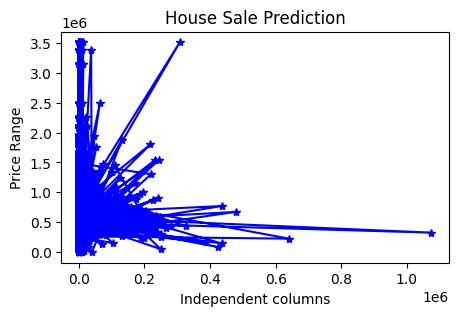

In [44]:
plt.figure(figsize=(5,3))
plt.title('House Sale Prediction')
plt.xlabel('Independent columns')
plt.ylabel('Price Range')
plt.plot(x_train,reg.predict(x_train),color='b',marker='*')
plt.show()

In [45]:
import pickle
with open('House_Price.pkl','wb') as p:
  pickle.dump(reg,p)

In [46]:
#load and check
with open('House_Price.pkl','rb') as p:
  e = pickle.load(p)